In [1]:
import sys
import os

# Get the absolute path of the project root
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))

In [2]:
import logging
import os
import warnings

# --- Disable Streamlit internal logs before it initializes ---
os.environ["STREAMLIT_SUPPRESS_LOGS"] = "1"
logging.getLogger(
    "streamlit.runtime.caching.cache_data_api").setLevel(logging.ERROR)
logging.getLogger("streamlit").setLevel(logging.ERROR)

# --- Suppress Python warnings ---
warnings.filterwarnings("ignore", category=FutureWarning, module="yfinance")
warnings.filterwarnings("ignore", category=UserWarning, module="streamlit")

In [3]:

import numpy as np
import pandas as pd
import streamlit as st
from scipy.stats.mstats import winsorize
from sklearn.preprocessing import MinMaxScaler, StandardScaler, FunctionTransformer
from sklearn.pipeline import Pipeline
from data.data_loader import load_data

2025-11-10 15:05:43.561 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager


### Preprocessing

In [4]:
df =  load_data('BTC-USD')
df.head()

2025-11-10 15:05:50.551 WARNING streamlit.runtime.caching.cache_data_api: No runtime found, using MemoryCacheStorageManager
c:\Users\parth\OneDrive - Southampton Solent University\COM724 - Assessment(AI)\data\data_loader.py:45: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(ticker, START_DATE, TODAY)
[*********************100%***********************]  1 of 1 completed


,Date,Close,High,Low,Open,Volume
0,2014-09-17,457.334015,468.174011,452.421997,465.864014,21056800
1,2014-09-18,424.440002,456.859985,413.104004,456.859985,34483200
2,2014-09-19,394.795990,427.834991,384.532013,424.102997,37919700
3,2014-09-20,408.903992,423.295990,389.882996,394.673004,36863600
4,2014-09-21,398.821014,412.425995,393.181000,408.084991,26580100


In [5]:
df.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume'], dtype='object')

In [8]:
df['Date'] = pd.to_datetime(df['Date'])
# Set Date as index for time series analysis
df.set_index('Date', inplace=True)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4072 entries, 2014-09-17 to 2025-11-09
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Close   4072 non-null   float64
 1   High    4072 non-null   float64
 2   Low     4072 non-null   float64
 3   Open    4072 non-null   float64
 4   Volume  4072 non-null   int64  
dtypes: float64(4), int64(1)
memory usage: 190.9 KB


In [10]:
df.describe()

,Close,High,Low,Open,Volume
count,4072.000000,4072.000000,4072.000000,4072.000000,4.072000e+03
mean,26036.855500,26539.856264,25457.254247,26012.325334,2.116517e+10
std,31017.295923,31529.769860,30432.257114,30996.196776,2.247330e+10
min,178.102997,211.731003,171.509995,176.897003,5.914570e+06
25%,2576.057495,2662.662598,2507.382507,2571.347595,1.178277e+09
50%,10514.534180,10772.027832,10216.135254,10486.077148,1.682117e+10
75%,40890.010742,42067.803711,39712.824219,40837.598633,3.261438e+10
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11


In [78]:
df.describe()

,Close,High,Low,Open,Volume,Close_Log,Close_Sqrt,Close_Cbrt,Close_Reciprocal,Close_YeoJohnson,Close_Standard,Close_MinMax,Close_Robust
count,4072.000000,4072.000000,4072.000000,4072.000000,4.072000e+03,4072.000000,4072.000000,4072.000000,4072.000000,4.072000e+03,4072.000000,4072.000000,4072.000000
mean,26036.855500,26539.856264,25457.254247,26012.325334,2.116517e+10,9.028680,130.865315,24.119837,0.000673,-1.675150e-16,0.000000,0.207577,0.405135
std,31017.295923,31529.769860,30432.257114,30996.196776,2.247330e+10,1.899351,94.410348,12.646642,0.001206,1.000123e+00,1.000123,0.248986,0.809556
min,178.102997,211.731003,171.509995,176.897003,5.914570e+06,5.187961,13.345523,5.626311,0.000008,-1.700938e+00,-0.833791,0.000000,-0.269782
25%,2576.057495,2662.662598,2507.382507,2571.347595,1.178277e+09,7.854403,50.754876,13.708350,0.000024,-7.557183e-01,-0.756471,0.019249,-0.207195
50%,10514.534180,10772.027832,10216.135254,10486.077148,1.682117e+10,9.260609,102.540402,21.907694,0.000095,-4.093041e-02,-0.500502,0.082974,0.000000
75%,40890.010742,42067.803711,39712.824219,40837.598633,3.261438e+10,10.618665,202.212767,34.451307,0.000388,8.447073e-01,0.478926,0.326808,0.792805
max,124752.531250,126198.070312,123196.046875,124752.140625,3.509679e+11,11.734095,353.203244,49.966982,0.005615,1.753207e+00,3.182992,1.000000,2.981629


In [ ]:
df.head()

In [12]:
df.isna().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [11]:
df.isnull().sum()

Close     0
High      0
Low       0
Open      0
Volume    0
dtype: int64

In [ ]:
# Optionally check percentage missing
# missing_pct = df.isna().mean() * 100

In [16]:
df.duplicated().sum()

0

In [20]:
df.shape

(4072, 5)

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

### EDA

### Checking the data is normally distributed or not

<Axes: xlabel='Close', ylabel='Density'>

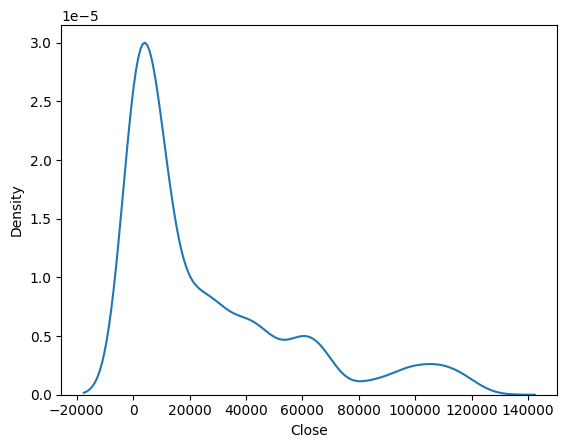

In [56]:
sns.kdeplot(df['Close'])

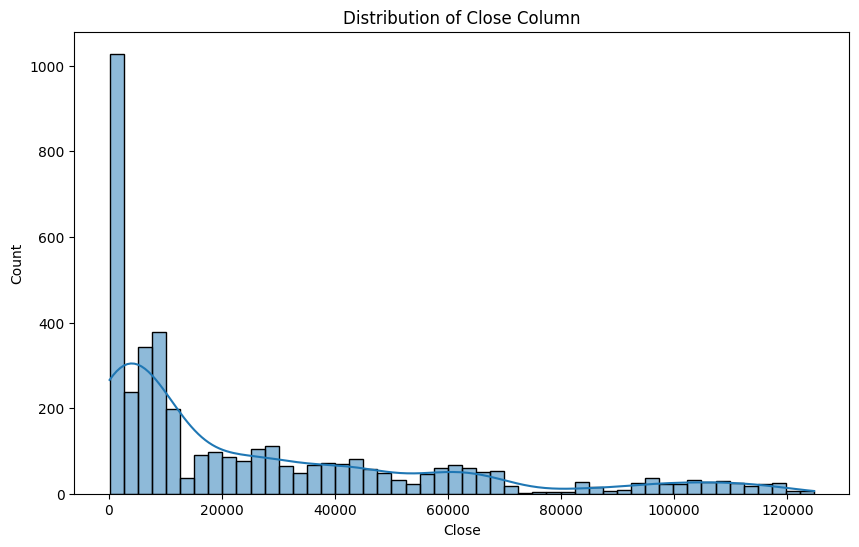

In [61]:

plt.figure(figsize=(10, 6))
sns.histplot(df['Close'], kde=True, bins=50)
plt.title('Distribution of Close Column')
plt.show()

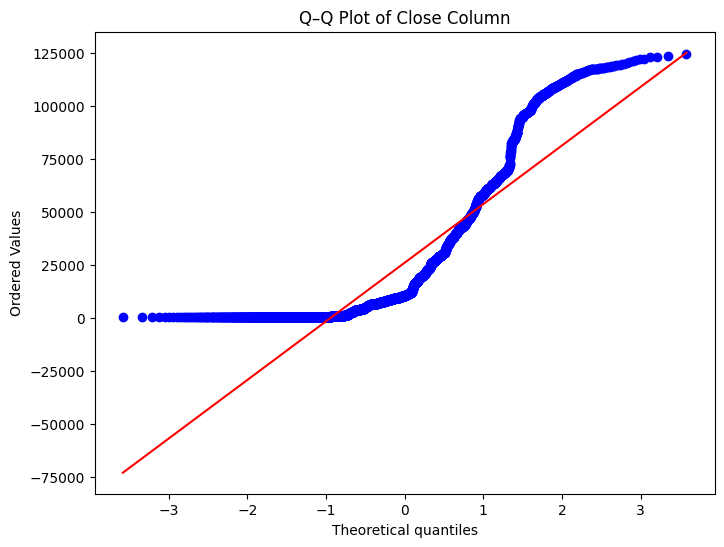

In [ ]:
# QQ Plot
# THIS GRAPH CHECKS IF DATA FOLLOWS A BELL CURVE

import scipy.stats as stats
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
stats.probplot(df['Close'], dist="norm", plot=plt)
plt.title("Q–Q Plot of Close Column")
plt.show()

# The straight line shows where points should be for perfect bell curve data
# Your actual data points curve away at both ends
#
# THIS MEANS: Your "Close Column" data has TOO MANY EXTREME VALUES
# - More very low values than expected (left side curves down)
# - More very high values than expected (right side curves up)
# - This pattern is common in volatile data like stock prices
#
# CONCLUSION: Not a bell curve - expect frequent extreme highs and lows

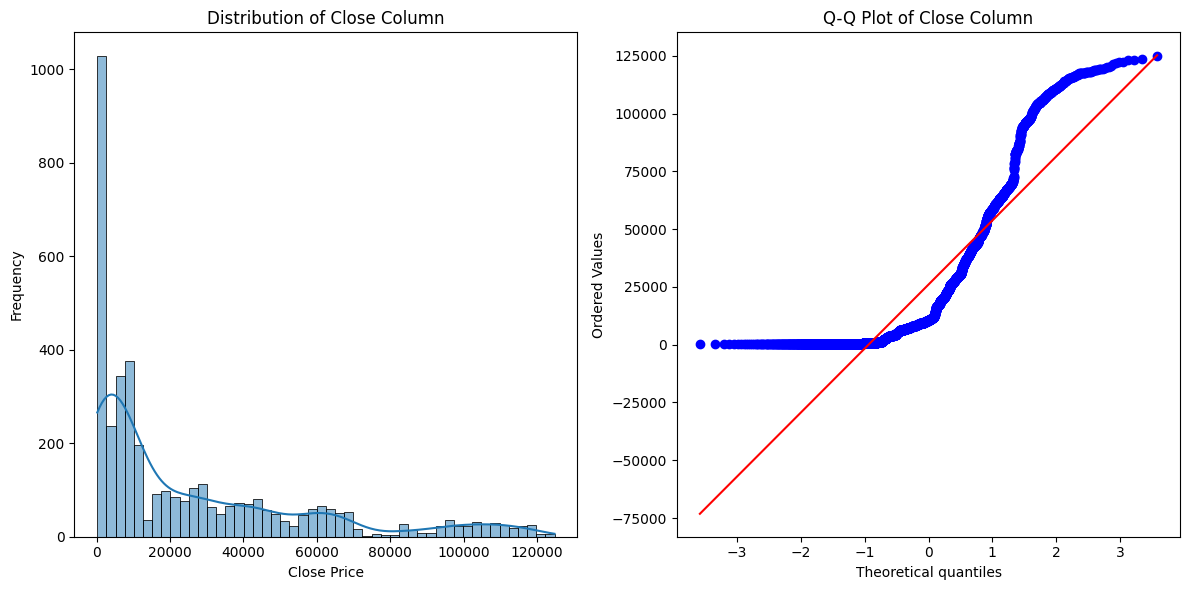

In [68]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Histogram with KDE on left subplot
sns.histplot(df['Close'], kde=True, bins=50, ax=ax1)
ax1.set_title('Distribution of Close Column')
ax1.set_xlabel('Close Price')
ax1.set_ylabel('Frequency')

# Q-Q Plot on right subplot
stats.probplot(df['Close'], dist="norm", plot=ax2)
ax2.set_title("Q-Q Plot of Close Column")
ax2.set_xlabel('Theoretical quantiles')
ax2.set_ylabel('Ordered Values')

# The straight line shows where points should be for perfect bell curve data
# Your actual data points curve away at both ends
#
# THIS MEANS: Your "Close Column" data has TOO MANY EXTREME VALUES
# - More very low values than expected (left side curves down)
# - More very high values than expected (right side curves up)
# - This pattern is common in volatile data like stock prices
#
# CONCLUSION: Not a bell curve - expect frequent extreme highs and lows

# Adjust layout and display
plt.tight_layout()
plt.show()

In [69]:
# The Data is right skewed and not normally distributed
# Applying Log Transformation to reduce skewness

trf = FunctionTransformer(func = np.log1p)
df['Close_Log'] = trf.transform(df[['Close']])  


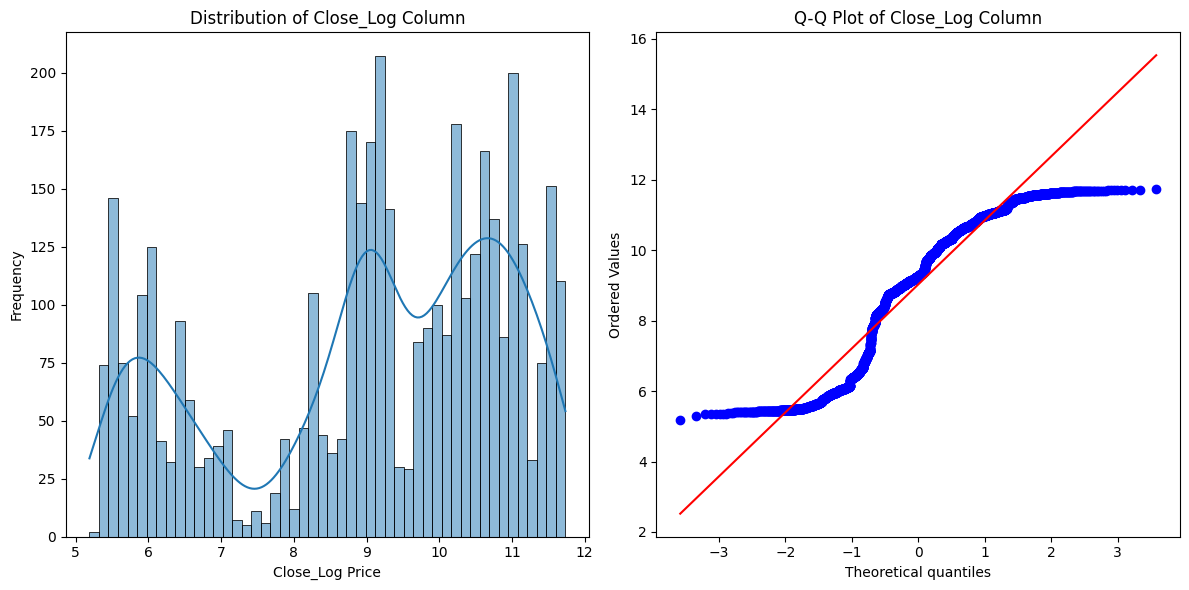

In [70]:
# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Histogram with KDE on left subplot
sns.histplot(df['Close_Log'], kde=True, bins=50, ax=ax1)
ax1.set_title('Distribution of Close_Log Column')
ax1.set_xlabel('Close_Log Price')
ax1.set_ylabel('Frequency')

# Q-Q Plot on right subplot
stats.probplot(df['Close_Log'], dist="norm", plot=ax2)
ax2.set_title("Q-Q Plot of Close_Log Column")
ax2.set_xlabel('Theoretical quantiles')
ax2.set_ylabel('Ordered Values')

plt.tight_layout()
plt.show()

In [71]:
from sklearn.preprocessing import RobustScaler
from sklearn.preprocessing import PowerTransformer

In [ ]:
transformations = {
    'Log': FunctionTransformer(np.log1p),
    'Sqrt': FunctionTransformer(np.sqrt),
    'Cbrt': FunctionTransformer(np.cbrt),
    'Reciprocal': FunctionTransformer(lambda x: 1 / (x + 1e-9)),
    'YeoJohnson': PowerTransformer(method='yeo-johnson'), # Yeo-Johnson works with zero/negative values
    'BoxCox': PowerTransformer(method='box-cox'), # Box-Cox requires all positive data
    'Standard': StandardScaler(),
    'MinMax': MinMaxScaler(),
    'Robust': RobustScaler()
}

for name, transformer in transformations.items():
    df[f'Close_{name}'] = transformer.fit_transform(df[['Close']])

In [81]:
df['Close_Reciprocal']

Date
2014-09-17    0.002187
2014-09-18    0.002356
2014-09-19    0.002533
2014-09-20    0.002446
2014-09-21    0.002507
                ...   
2025-11-05    0.000010
2025-11-06    0.000010
2025-11-07    0.000010
2025-11-08    0.000010
2025-11-09    0.000010
Name: Close_Reciprocal, Length: 4072, dtype: float64

In [100]:
df.columns

Index(['Close', 'High', 'Low', 'Open', 'Volume', 'Close_Log', 'Close_Sqrt',
       'Close_Cbrt', 'Close_Reciprocal', 'Close_YeoJohnson', 'Close_Standard',
       'Close_MinMax', 'Close_Robust', 'Close_BoxCox'],
      dtype='object')

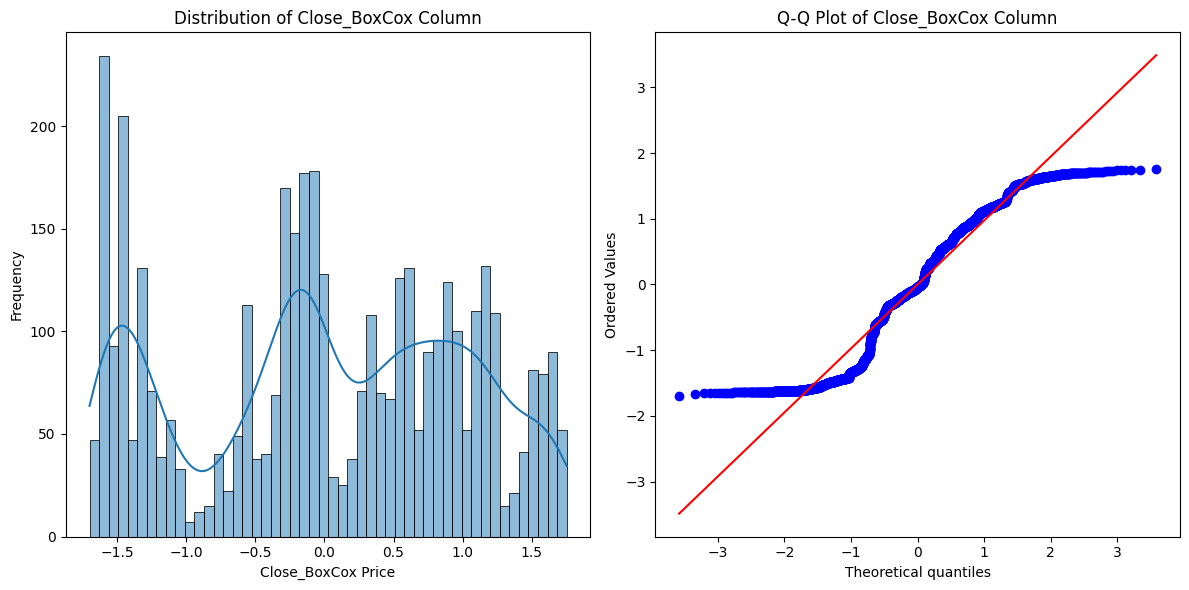

In [101]:
# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

# Histogram with KDE on left subplot
sns.histplot(df['Close_BoxCox'], kde=True, bins=50, ax=ax1)
ax1.set_title('Distribution of Close_BoxCox Column')
ax1.set_xlabel('Close_BoxCox Price')
ax1.set_ylabel('Frequency')

# Q-Q Plot on right subplot
stats.probplot(df['Close_BoxCox'], dist="norm", plot=ax2)
ax2.set_title("Q-Q Plot of Close_BoxCox Column")
ax2.set_xlabel('Theoretical quantiles')
ax2.set_ylabel('Ordered Values')

plt.tight_layout()
plt.show()

<Axes: xlabel='Close_BoxCox'>

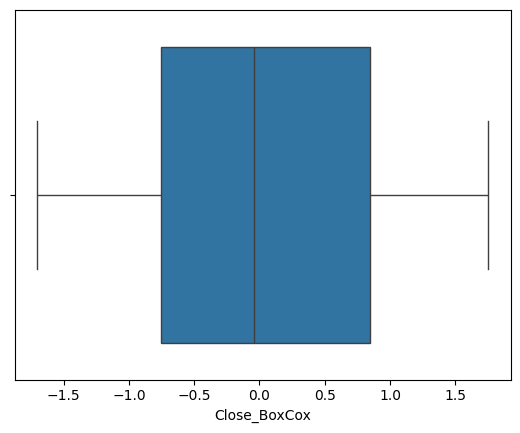

In [102]:
sns.boxplot(df['Close_BoxCox'], orient='h')

In [91]:
df['Close'].describe()

count      4072.000000
mean      26036.855500
std       31017.295923
min         178.102997
25%        2576.057495
50%       10514.534180
75%       40890.010742
max      124752.531250
Name: Close, dtype: float64

### A. Univariate Analysis (Understanding individual variables)


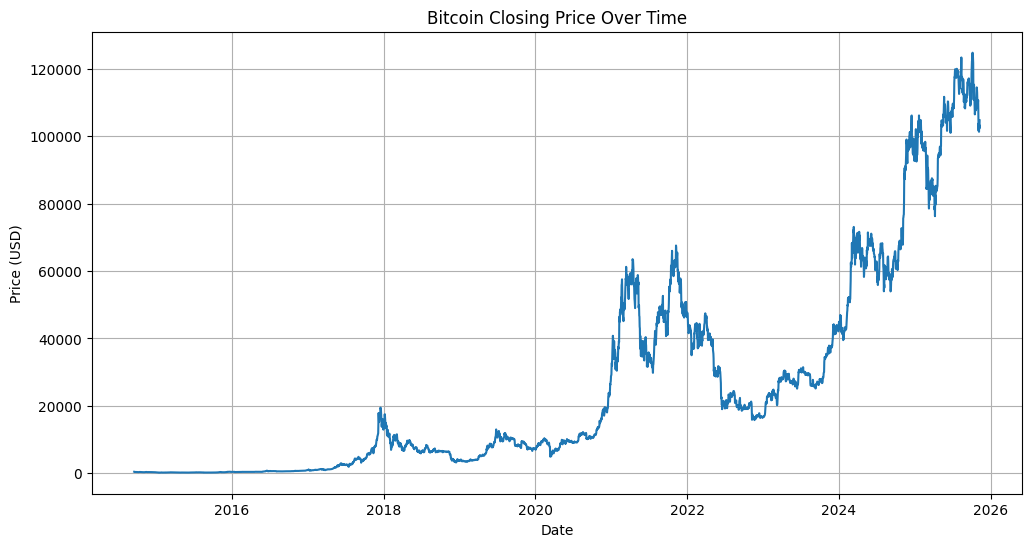

In [95]:
# Time Series Plot
%matplotlib inline 
# Ensures plots display inside the Jupyter Notebook
plt.figure(figsize=(12, 6))
plt.plot(df.index, df['Close'])
plt.title('Bitcoin Closing Price Over Time')
plt.ylabel('Price (USD)')
plt.xlabel('Date')
plt.grid(True)
plt.show()

In [ ]:
df['Daily_Return'] = df['Close'].pct_change() * 100

In [ ]:
# Distribution of Daily Returns
import seaborn as sns
plt.figure(figsize=(12, 6))
sns.histplot(df['Daily_Return'].dropna(), kde=True, bins=100)
plt.title('Distribution of Daily Returns')
plt.show()

### B. Bivariate Analysis (Understanding each variables)


### C. Multivariate Analysis (Relation between variables)


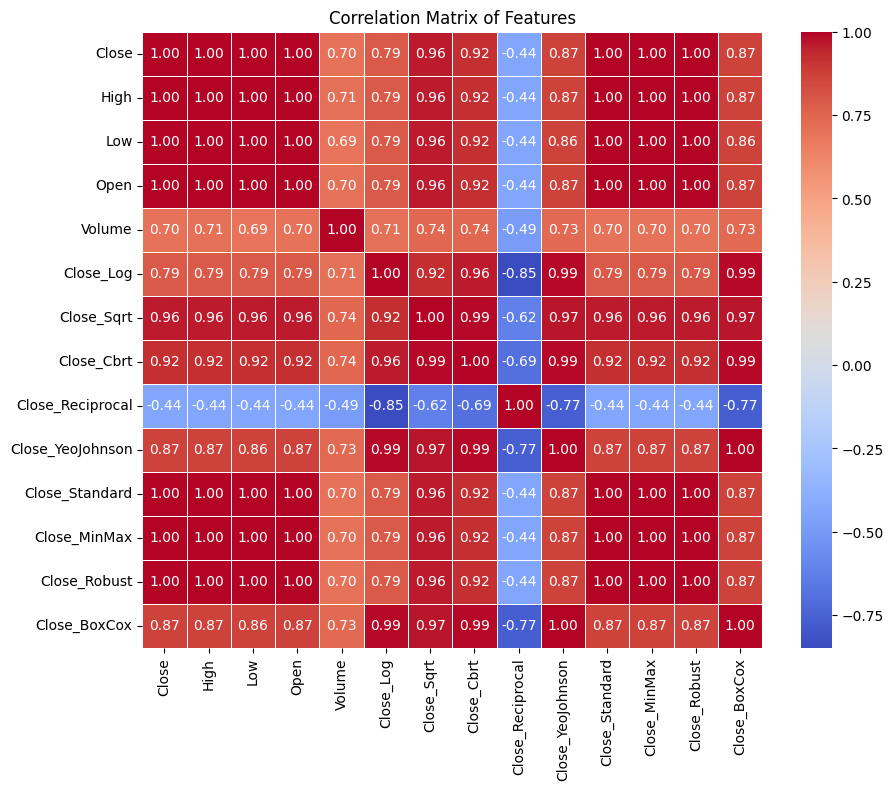

In [103]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True,
            cmap='coolwarm', fmt='.2f', linewidths=0.5)
plt.title('Correlation Matrix of Features')
plt.show()

# --- Correlation Matrix Explaination ---

# OHLC features (Open, High, Low, Close) show almost perfect correlation (~1.00) with each other

# If the market is up, all four go up.
# If the market is down, all four go down.
# When trading volume increases, price tends to be higher.

In [ ]:
df['Day_of_Week'] = df.index.dayofweek
df['Month'] = df.index.month
df['Year'] = df.index.year
df['Quarter'] = df.index.quarter

In [ ]:


sns.boxplot(x='Day_of_Week', y='Daily_Return', data=df)
plt.title('Daily Returns by Day of the Week')
plt.xlabel('Day of the Week (0=Monday, 6=Sunday)')
plt.ylabel('Daily Return (%)')
plt.show()

In [ ]:
sns.boxplot(x='Month', y='Daily_Return', data=df)
plt.title('Monthly Returns by Day of the Week')
plt.xlabel('Months (1=Jan, 12=Dec)')
plt.ylabel('Monthly Return (%)')
plt.show()